# Transfer Learning với MobileNetV2

Phân loại 38 lớp bệnh lá cây từ bộ dữ liệu PlantVillage.

1. Import thư viện và cấu hình
2. Nạp dữ liệu và xử lý ảnh
3. Xây dựng MobileNetV2
4. Huấn luyện hai giai đoạn
5. Đánh giá trên tập test

Model tốt nhất được giữ trong RAM trong lúc chạy notebook, không tự động lưu ra file.

## Bước 1 – Import thư viện và cấu hình

Đặt batch size, số epoch, learning rate và seed. Notebook tự dùng GPU nếu CUDA khả dụng.

In [27]:
from pathlib import Path
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2

ROOT = Path.cwd() if (Path.cwd() / "notebooks").exists() else Path.cwd().parent
RESULTS_DIR = ROOT / "outputs" / "results"

configured_data_dir = os.getenv("DATA_DIR")
env_path = ROOT / ".env"
if not configured_data_dir and env_path.exists():
    for line in env_path.read_text(encoding="utf-8").splitlines():
        key, separator, value = line.partition("=")
        if separator and key.strip() == "DATA_DIR":
            configured_data_dir = value.strip().strip("\"'")
            break

DATA_DIR = Path(configured_data_dir) if configured_data_dir else ROOT.parent / "PlantVillage"
if not DATA_DIR.is_absolute():
    DATA_DIR = ROOT / DATA_DIR
DATA_DIR = DATA_DIR.expanduser().resolve()

MANIFEST_PATH = ROOT / "data" / "preprocessing_data.csv"

IMAGE_SIZE = 224
BATCH_SIZE = 32
PHASE1_EPOCHS = 5
PHASE2_EPOCHS = 5
PHASE1_LR = 1e-3
PHASE2_LR = 1e-4
UNFREEZE_LAST_BLOCKS = 3
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.11.0+cu128
Device: cuda


## Bước 2 – Nạp dữ liệu và xử lý ảnh

Đọc `preprocessing_data.csv` được tạo bởi notebook preprocessing mới và kiểm tra nhãn trước khi tạo DataLoader.

- Đọc ảnh gốc trong thư mục `PlantVillage` theo cột `relative_path`.
- Ảnh được chuyển sang RGB và resize thành 224×224 khi nạp.
- Train dùng lật ngang và xoay nhẹ để tăng tính đa dạng.
- Validation và test không augmentation.
- Cả ba tập dùng mean và standard deviation của MobileNetV2 pretrained.

In [16]:
if not MANIFEST_PATH.exists():
    raise FileNotFoundError("Hãy chạy 02_preprocessing.ipynb trước.")
if not DATA_DIR.is_dir():
    raise FileNotFoundError(f"Không tìm thấy thư mục dữ liệu: {DATA_DIR}")

data = pd.read_csv(MANIFEST_PATH)
required_columns = {"relative_path", "class_name", "class_id", "split"}
missing_columns = required_columns - set(data.columns)
if missing_columns:
    raise ValueError(f"preprocessing_data.csv thiếu cột: {sorted(missing_columns)}")

classes = data[["class_id", "class_name"]].drop_duplicates().sort_values("class_id")
if classes["class_id"].tolist() != list(range(len(classes))):
    raise ValueError("class_id phải liên tục và bắt đầu từ 0.")

class_names = classes["class_name"].tolist()
class_to_id = {name: index for index, name in enumerate(class_names)}
expected_ids = data["class_name"].map(class_to_id)
if expected_ids.isna().any() or not np.array_equal(data["class_id"], expected_ids):
    raise ValueError("class_id không khớp với class_name.")

print("File dữ liệu:", MANIFEST_PATH)
print("Thư mục ảnh:", DATA_DIR)
display(pd.crosstab(data["split"], data["class_name"]))

File dữ liệu: c:\Users\MY PC\Documents\DL\project 1\plant-disease-classification\outputs\results\preprocessing_data.csv
Thư mục ảnh: C:\Users\MY PC\Documents\DL\project 1\archive\PlantVillage


class_name,Apple___Apple_scab,Apple___Black_rot,Apple___Cedar_apple_rust,Apple___healthy,Blueberry___healthy,Cherry_(including_sour)___Powdery_mildew,Cherry_(including_sour)___healthy,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,Corn_(maize)___Common_rust_,Corn_(maize)___Northern_Leaf_Blight,...,Tomato___Bacterial_spot,Tomato___Early_blight,Tomato___Late_blight,Tomato___Leaf_Mold,Tomato___Septoria_leaf_spot,Tomato___Spider_mites Two-spotted_spider_mite,Tomato___Target_Spot,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Tomato_mosaic_virus,Tomato___healthy
split,,,,,,,,,,,,,,,,,,,,,
test,126,125,55,324,300,210,170,103,239,197,...,425,200,379,191,354,335,281,1071,74,316
train,454,446,198,1182,1082,758,616,369,858,709,...,1532,720,1370,685,1275,1207,1011,3857,269,1142
validation,50,50,22,132,120,84,68,41,95,79,...,170,80,152,76,142,134,112,429,30,127


In [17]:
weights = MobileNet_V2_Weights.DEFAULT
preprocessing = weights.transforms()
normalize = transforms.Normalize(preprocessing.mean, preprocessing.std)

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    normalize,
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    normalize,
])


class PlantDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.paths = dataframe["relative_path"].astype(str).tolist()
        self.labels = dataframe["class_id"].astype(int).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        image_path = DATA_DIR / self.paths[index]
        with Image.open(image_path) as image:
            image = self.transform(image.convert("RGB"))
        return image, self.labels[index]


def make_dataset(split, transform):
    part = data[data["split"] == split].reset_index(drop=True)
    if part.empty:
        raise ValueError(f"Split {split} không có dữ liệu.")
    return PlantDataset(part, transform)


train_dataset = make_dataset("train", train_transform)
val_dataset = make_dataset("validation", eval_transform)
test_dataset = make_dataset("test", eval_transform)

sample_path = DATA_DIR / train_dataset.paths[0]
if not sample_path.is_file():
    raise FileNotFoundError(f"Không tìm thấy ảnh: {sample_path}")

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": 0,
    "pin_memory": DEVICE.type == "cuda",
}
generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset, shuffle=True, generator=generator, **loader_options
)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 39089
Validation: 4344
Test: 10851


## Bước 3 – Xây dựng MobileNetV2

Dùng MobileNetV2 đã học từ ImageNet làm backbone. Lớp phân loại cuối được thay bằng `Linear` có 38 đầu ra.

Ở giai đoạn đầu, backbone được đóng băng và chỉ classifier được huấn luyện. Loss dùng `CrossEntropyLoss` vì nhãn là số nguyên.

In [18]:
model = mobilenet_v2(weights=weights)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(class_names))
model = model.to(DEVICE)

for parameter in model.features.parameters():
    parameter.requires_grad = False

criterion = nn.CrossEntropyLoss()
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=38, bias=True)
)


## Bước 4 – Huấn luyện

Huấn luyện gồm hai giai đoạn:

- **Phase 1:** chỉ học classifier mới với learning rate `0.001`.
- **Phase 2:** mở 3 block cuối của backbone và fine-tune với learning rate `0.0001`.

Sau mỗi epoch, model có validation loss thấp nhất được giữ trong RAM, không ghi checkpoint ra ổ đĩa.

In [19]:
def run_epoch(loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    if training:
        model.features.eval()

    total_loss = 0.0
    total_correct = 0
    total_images = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * len(labels)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total_images += len(labels)

    return total_loss / total_images, total_correct / total_images


def train_phase(name, epochs, learning_rate):
    optimizer = torch.optim.AdamW(
        (parameter for parameter in model.parameters() if parameter.requires_grad),
        lr=learning_rate,
        weight_decay=1e-4,
    )
    history = []
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = run_epoch(train_loader, optimizer)
        val_loss, val_accuracy = run_epoch(val_loader)
        history.append({
            "phase": name,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": val_loss,
            "validation_accuracy": val_accuracy,
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"{name} {epoch}/{epochs} | "
            f"loss: {train_loss:.4f} - acc: {train_accuracy:.4f} | "
            f"val_loss: {val_loss:.4f} - val_acc: {val_accuracy:.4f}"
        )

    return history, best_val_loss, best_state

In [20]:
phase1_history, phase1_best_loss, phase1_state = train_phase(
    "Transfer learning", PHASE1_EPOCHS, PHASE1_LR
)

model.load_state_dict(phase1_state)
for block in model.features[-UNFREEZE_LAST_BLOCKS:]:
    for parameter in block.parameters():
        parameter.requires_grad = True

phase2_history, phase2_best_loss, phase2_state = train_phase(
    "Fine-tuning", PHASE2_EPOCHS, PHASE2_LR
)

use_phase2 = phase2_best_loss <= phase1_best_loss
best_state = phase2_state if use_phase2 else phase1_state
model.load_state_dict(best_state)

history = pd.DataFrame(phase1_history + phase2_history)
history["epoch"] = range(1, len(history) + 1)
print("Model được chọn:", "Phase 2" if use_phase2 else "Phase 1")

Transfer learning 1/5 | loss: 0.6693 - acc: 0.8572 | val_loss: 0.2986 - val_acc: 0.9282
Transfer learning 2/5 | loss: 0.2412 - acc: 0.9393 | val_loss: 0.2011 - val_acc: 0.9503
Transfer learning 3/5 | loss: 0.1828 - acc: 0.9502 | val_loss: 0.1676 - val_acc: 0.9507
Transfer learning 4/5 | loss: 0.1525 - acc: 0.9569 | val_loss: 0.1460 - val_acc: 0.9574
Transfer learning 5/5 | loss: 0.1352 - acc: 0.9606 | val_loss: 0.1297 - val_acc: 0.9606
Fine-tuning 1/5 | loss: 0.1308 - acc: 0.9568 | val_loss: 0.0807 - val_acc: 0.9751
Fine-tuning 2/5 | loss: 0.0811 - acc: 0.9729 | val_loss: 0.0923 - val_acc: 0.9680
Fine-tuning 3/5 | loss: 0.0617 - acc: 0.9790 | val_loss: 0.0957 - val_acc: 0.9703
Fine-tuning 4/5 | loss: 0.0528 - acc: 0.9821 | val_loss: 0.0826 - val_acc: 0.9728
Fine-tuning 5/5 | loss: 0.0432 - acc: 0.9853 | val_loss: 0.0814 - val_acc: 0.9724
Model được chọn: Phase 2


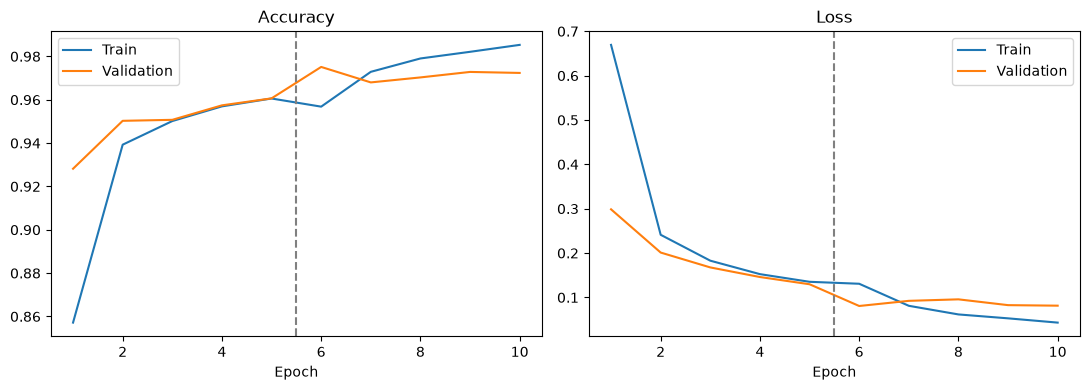

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, metric in zip(axes, ["accuracy", "loss"]):
    ax.plot(history["epoch"], history[f"train_{metric}"], label="Train")
    ax.plot(
        history["epoch"],
        history[f"validation_{metric}"],
        label="Validation",
    )
    ax.axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle="--")
    ax.set(xlabel="Epoch", title=metric.capitalize())
    ax.legend()

plt.tight_layout()
plt.show()

## Bước 5 – Đánh giá trên tập test

Đánh giá model tốt nhất sau khi đã chọn bằng validation. Accuracy cho biết tỷ lệ dự đoán đúng; macro F1 xem các lớp có trọng số ngang nhau.

Confusion matrix có hàng là nhãn thật và cột là nhãn dự đoán. Tập test chỉ được dùng một lần ở bước cuối.

,precision,recall,f1-score,support
Apple___Apple_scab,0.9918,0.9603,0.9758,126.0000
Apple___Black_rot,0.9920,0.9920,0.9920,125.0000
Apple___Cedar_apple_rust,1.0000,0.9455,0.9720,55.0000
Apple___healthy,0.9968,0.9568,0.9764,324.0000
Blueberry___healthy,0.9900,0.9933,0.9917,300.0000
Cherry_(including_sour)___Powdery_mildew,1.0000,0.9810,0.9904,210.0000
Cherry_(including_sour)___healthy,0.9940,0.9765,0.9852,170.0000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.9176,0.7573,0.8298,103.0000
Corn_(maize)___Common_rust_,1.0000,0.9916,0.9958,239.0000
Corn_(maize)___Northern_Leaf_Blight,0.8843,0.9695,0.9249,197.0000


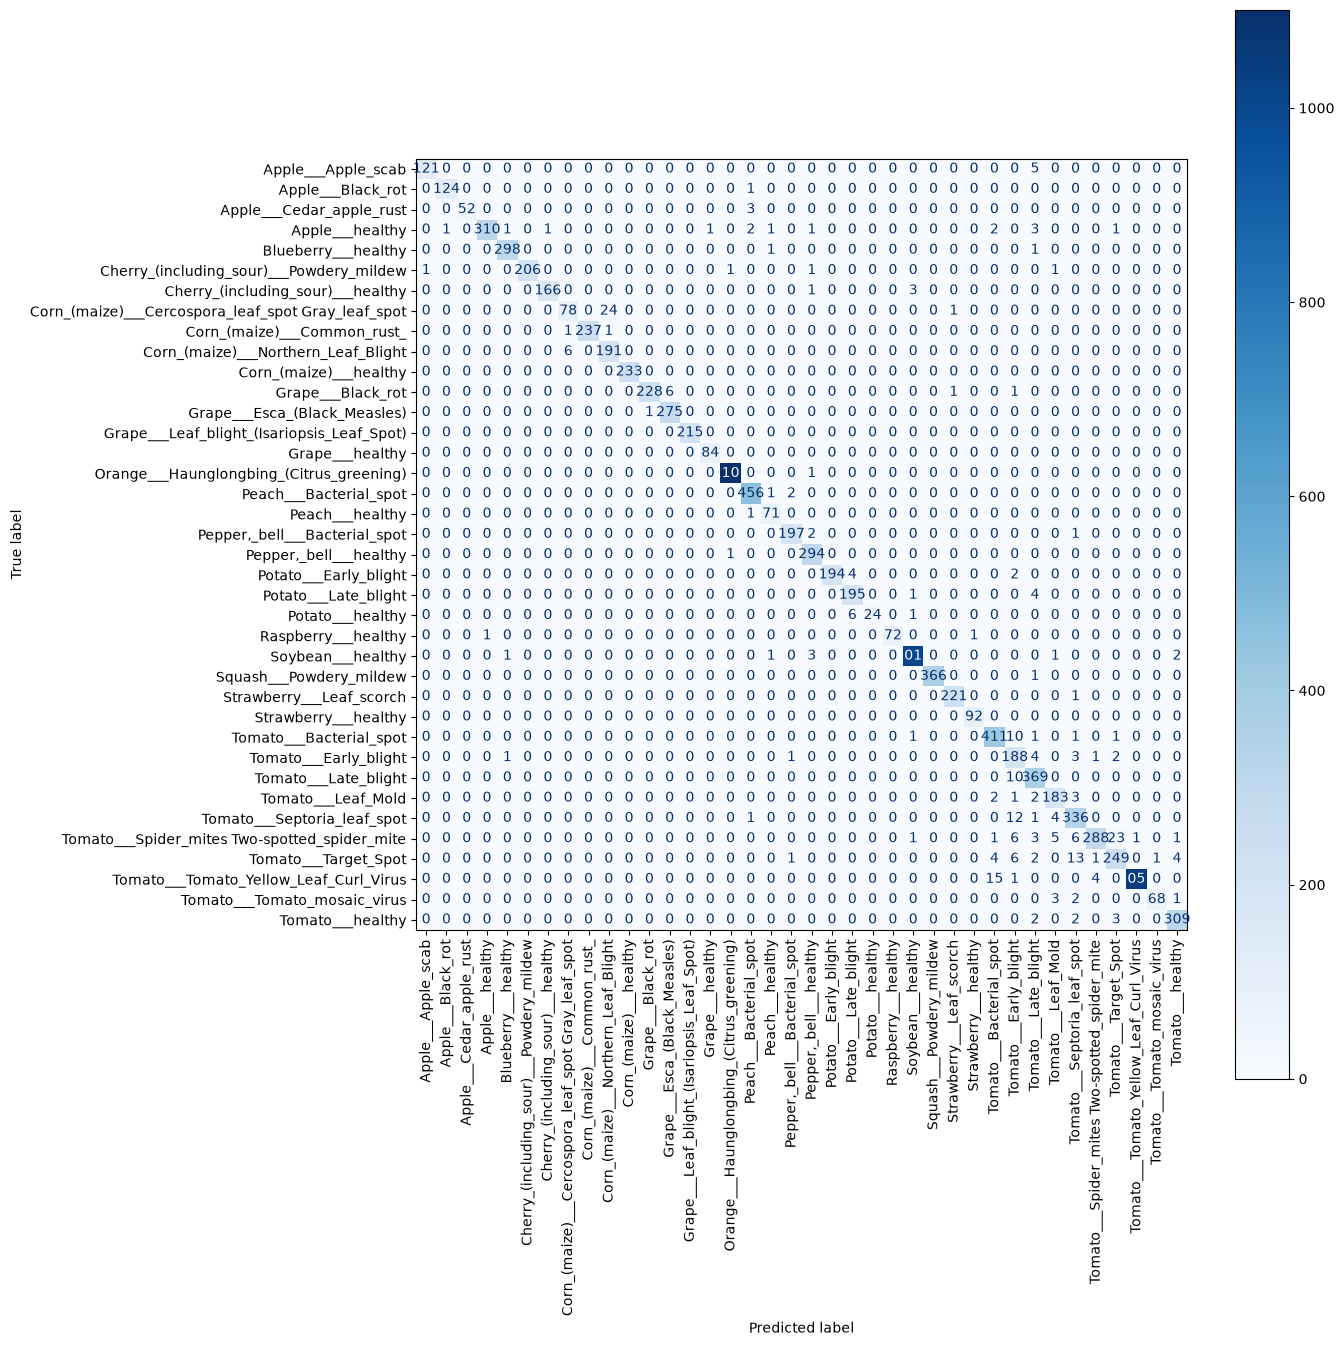

Test loss: 0.0781
Accuracy: 97.35% | Macro F1: 0.9648


In [22]:
test_loss, test_accuracy = run_epoch(test_loader)
y_true, y_pred = [], []

model.eval()
with torch.inference_mode():
    for images, labels in test_loader:
        predictions = model(images.to(DEVICE)).argmax(1).cpu()
        y_true.extend(labels.tolist())
        y_pred.extend(predictions.tolist())

report = classification_report(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
matrix = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

display(pd.DataFrame(report).T.round(4))
fig, ax = plt.subplots(figsize=(14, 14))
ConfusionMatrixDisplay(matrix, display_labels=class_names).plot(
    cmap="Blues", xticks_rotation=90, values_format="d", ax=ax
)
plt.tight_layout()
plt.show()

macro_f1 = report["macro avg"]["f1-score"]
print(f"Test loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.2%} | Macro F1: {macro_f1:.4f}")

## Confusion matrix cho nhóm Tomato

Phần này dùng lại `y_true`, `y_pred` và `class_names` ở trên. Ma trận 10×10 chỉ gồm các mẫu có nhãn thật thuộc nhóm Tomato; các dự đoán sang nhóm cây khác được thống kê riêng.

In [28]:
import seaborn as sns

y_true, y_pred = [], []
model.eval()

with torch.inference_mode():
    for images, labels in test_loader:
        predictions = model(images.to(DEVICE)).argmax(1).cpu()
        y_true.extend(labels.tolist())
        y_pred.extend(predictions.tolist())

tomato_classes = [
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___healthy",
]

missing_classes = [name for name in tomato_classes if name not in class_names]
if missing_classes:
    raise ValueError(f"Không tìm thấy lớp Tomato: {missing_classes}")

tomato_ids = [class_names.index(name) for name in tomato_classes]
tomato_names = [name.removeprefix("Tomato___") for name in tomato_classes]

y_true_array = np.asarray(y_true)
y_pred_array = np.asarray(y_pred)
tomato_mask = np.isin(y_true_array, tomato_ids)
tomato_y_true = y_true_array[tomato_mask]
tomato_y_pred = y_pred_array[tomato_mask]

if len(tomato_y_true) == 0:
    raise ValueError("Không có mẫu Tomato trong y_true.")

tomato_matrix = confusion_matrix(
    tomato_y_true, tomato_y_pred, labels=tomato_ids
)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    tomato_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=tomato_names,
    yticklabels=tomato_names,
    annot_kws={"size": 9},
    ax=ax,
)
ax.set_title("Confusion Matrix - Tomato Disease Classes", fontsize=14, pad=12)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.tick_params(axis="x", labelrotation=45, labelsize=9)
ax.tick_params(axis="y", labelrotation=0, labelsize=9)
plt.setp(ax.get_xticklabels(), ha="right")
plt.tight_layout()

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
tomato_matrix_path = RESULTS_DIR / "tomato_confusion_matrix.png"
fig.savefig(tomato_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

outside_mask = ~np.isin(tomato_y_pred, tomato_ids)
outside_predictions = pd.DataFrame({
    "true_label": [
        class_names[label].removeprefix("Tomato___")
        for label in tomato_y_true[outside_mask]
    ],
    "predicted_label": [class_names[label] for label in tomato_y_pred[outside_mask]],
})

print(f"Đã lưu: {tomato_matrix_path}")
print(f"Số mẫu Tomato: {len(tomato_y_true)}")
print(f"Accuracy nhóm Tomato: {(tomato_y_true == tomato_y_pred).mean():.2%}")
print(f"Dự đoán sang lớp ngoài Tomato: {outside_mask.sum()}")

if outside_predictions.empty:
    print("Không có mẫu Tomato nào bị dự đoán sang nhóm cây khác.")
else:
    outside_summary = (
        outside_predictions.value_counts(["true_label", "predicted_label"])
        .rename("count")
        .reset_index()
        .sort_values(["true_label", "count"], ascending=[True, False])
    )
    display(outside_summary)

precision, recall, f1, support = precision_recall_fscore_support(
    y_true_array,
    y_pred_array,
    labels=tomato_ids,
    zero_division=0,
)
class_accuracy = [
    ((y_true_array == class_id) == (y_pred_array == class_id)).mean()
    for class_id in tomato_ids
]

tomato_metrics = pd.DataFrame({
    "class_name": tomato_names,
    "accuracy": class_accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support,
})
print("Metrics từng lớp Tomato (one-vs-rest trên toàn bộ tập test):")
display(tomato_metrics.round(4))

ModuleNotFoundError: No module named 'seaborn'